<a href="https://colab.research.google.com/github/laceywang11/MSSP6070/blob/main/Week_12_Participation_Exercise_Lacey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **General Analysis of Student Performance**

1. Import Files

In [2]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving Student Performance Data.csv to Student Performance Data.csv


In [4]:
df = pd.read_csv('Student Performance Data.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,72,74,218,none,medium
1,female,group C,some college,standard,69,90,88,247,completed,high
2,female,group B,master's degree,standard,90,95,93,278,none,high
3,male,group A,associate's degree,free/reduced,47,57,44,148,none,low
4,male,group C,some college,standard,76,78,75,229,none,high


2. Independent T-test

In [5]:
male_math = df[df['gender'] == 'male']['math score']
female_math = df[df['gender'] == 'female']['math score']

male_math[:5], female_math[:5]

(3     47
 4     76
 7     40
 8     64
 10    58
 Name: math score, dtype: int64,
 0    72
 1    69
 2    90
 5    71
 6    88
 Name: math score, dtype: int64)

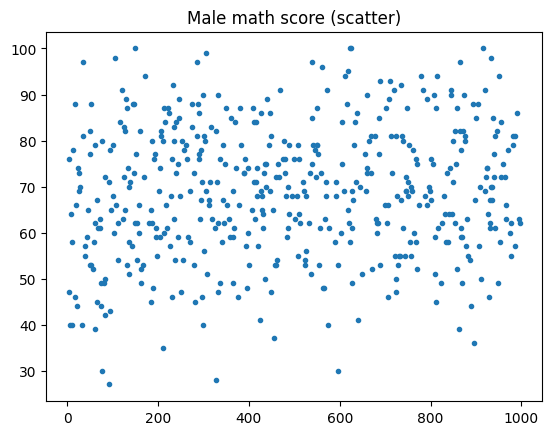

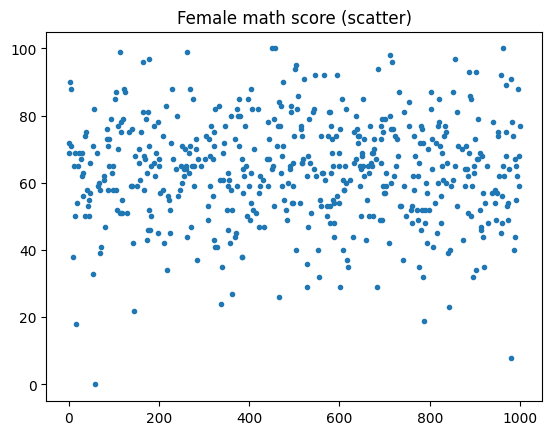

In [8]:
import matplotlib.pyplot as plt
from scipy import stats

#Scatter plot
plt.plot(male_math, '.')
plt.title("Male math score (scatter)")
plt.show()

plt.plot(female_math, '.')
plt.title("Female math score (scatter)")
plt.show()

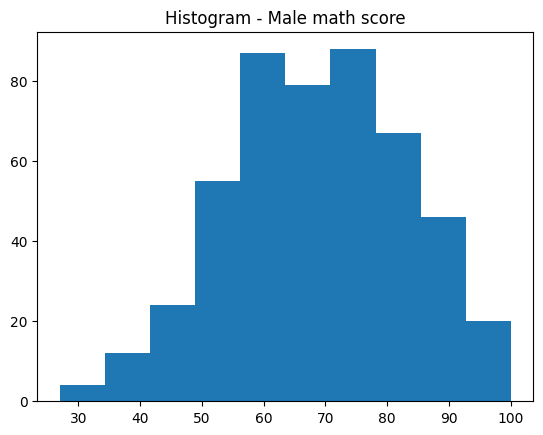

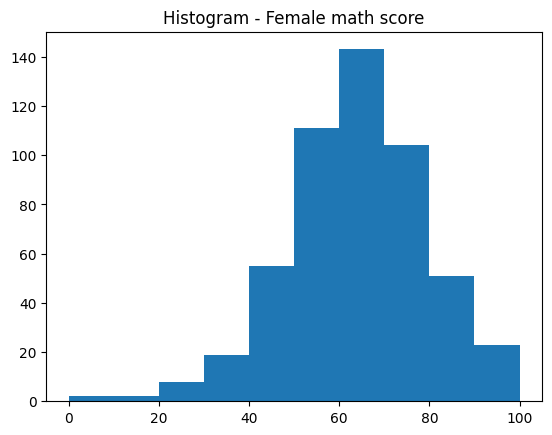

In [9]:
#Histogram
plt.hist(male_math)
plt.title("Histogram - Male math score")
plt.show()

plt.hist(female_math)
plt.title("Histogram - Female math score")
plt.show()

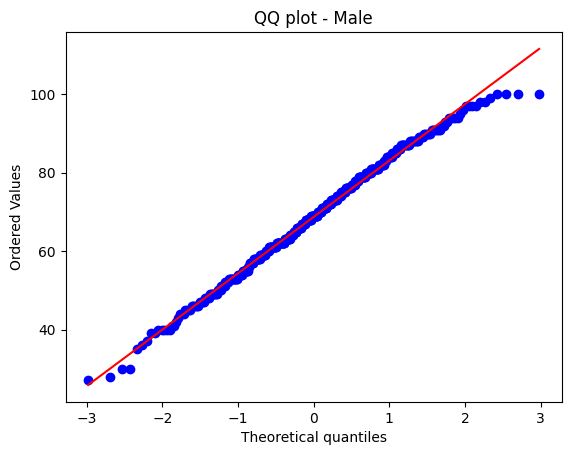

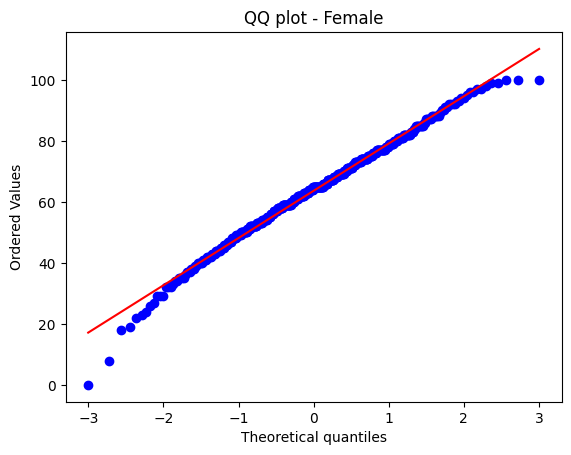

In [10]:
#QQ-plot
stats.probplot(male_math, plot=plt)
plt.title("QQ plot - Male")
plt.show()

stats.probplot(female_math, plot=plt)
plt.title("QQ plot - Female")
plt.show()

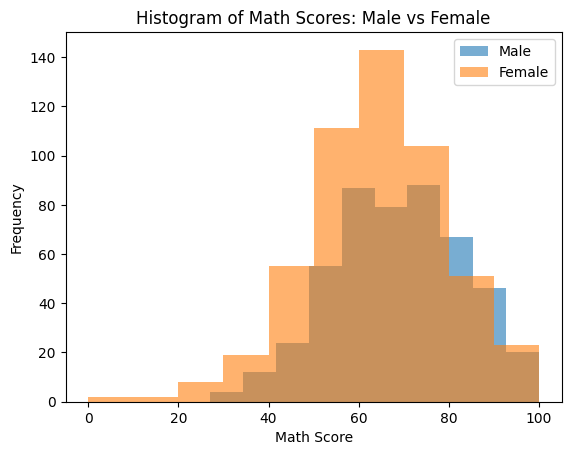

In [13]:
#Combine Together to Compare
plt.hist(male_math, alpha=0.6, label='Male')
plt.hist(female_math, alpha=0.6, label='Female')
plt.legend()
plt.title('Histogram of Math Scores: Male vs Female')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

3. T-test

In [15]:
t, p = stats.ttest_ind(male_math, female_math, equal_var=False)
t, p
#The difference in math scores between males and females is statistically significant(t = 5.40, p < 0.001).
#In this sample, males scored significantly higher on average.

(np.float64(5.398000564160736), np.float64(8.420838109090415e-08))

# **Is there a difference between males who took the preparation exam and others?**

In [16]:
# Group A: males who completed the prep course
groupA = df[(df['gender'] == 'male') & (df['test preparation course'] == 'completed')]['math score']

# Group B: everyone else
groupB = df[~((df['gender'] == 'male') & (df['test preparation course'] == 'completed'))]['math score']

len(groupA), len(groupB)

(174, 826)

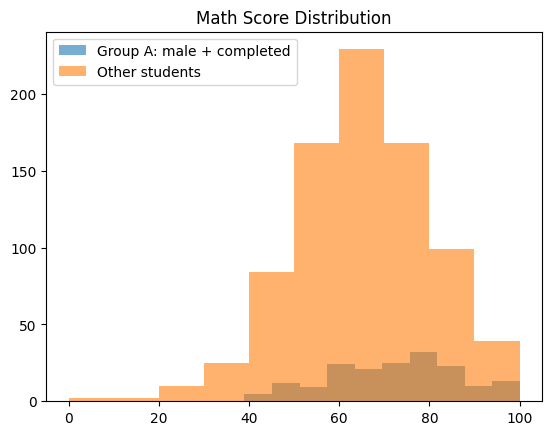

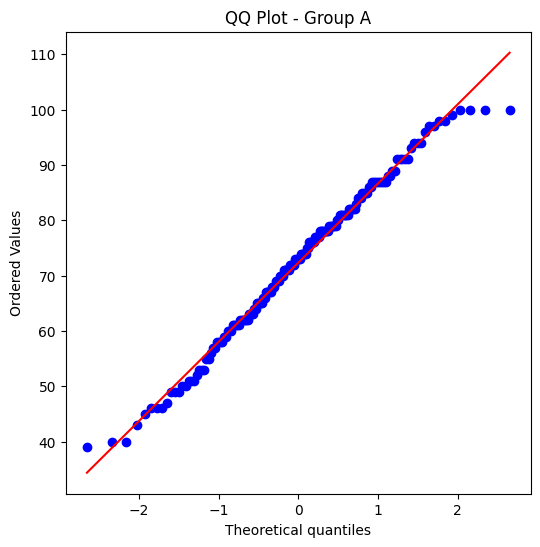

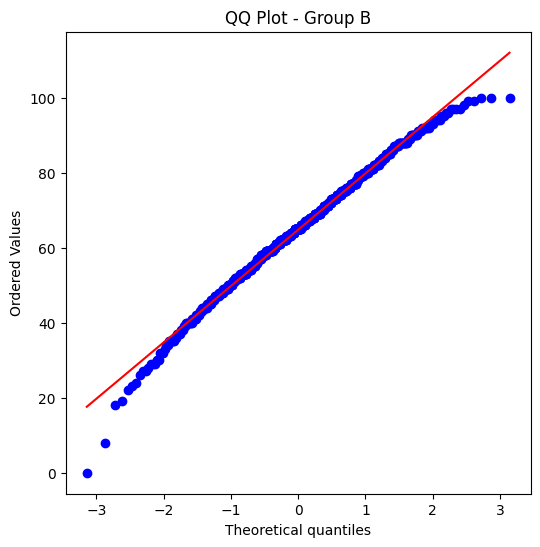

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Histogram
plt.hist(groupA, alpha=0.6, label='Group A: male + completed')
plt.hist(groupB, alpha=0.6, label='Other students')
plt.legend()
plt.title("Math Score Distribution")
plt.show()

# QQ Plot
plt.figure(figsize=(6, 6))
stats.probplot(groupA, plot=plt)
plt.title("QQ Plot - Group A")
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(groupB, plot=plt)
plt.title("QQ Plot - Group B")
plt.show()

In [18]:
t2, p2 = stats.ttest_ind(groupA, groupB, equal_var=False)
t2, p2
#Because p < 0.05, there is a statistically significant difference.
#Group A(males who took the preparation exam) has significantly higher math scores than the rest of the students.

(np.float64(6.3142351155149345), np.float64(1.1616520122747526e-09))

# **Whether Completing the Prep Courses Influence Writing Scores?**

In [19]:
prep = df[df['test preparation course']=='completed']['writing score']
no_prep = df[df['test preparation course']=='none']['writing score']

# t-test
t3, p3 = stats.ttest_ind(prep, no_prep, equal_var=False)
t3, p3
#According to the results, Students who completed the prep course performed much better in writing,
#and the difference is statistically very strong.(t ≈ 10.75,p < 0.000000000000000000000026)

(np.float64(10.752510233886923), np.float64(2.662740173941066e-25))

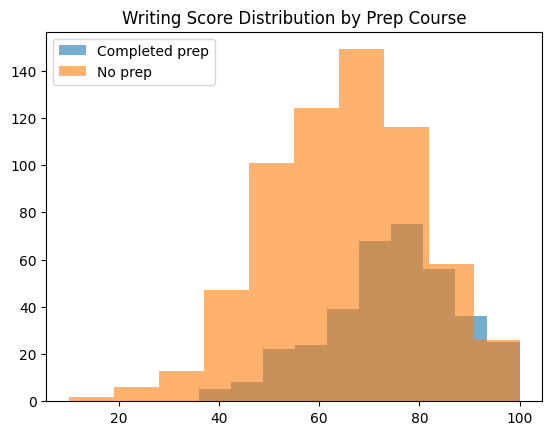

In [20]:
#Histogram
plt.hist(prep, alpha=0.6, label='Completed prep')
plt.hist(no_prep, alpha=0.6, label='No prep')
plt.legend()
plt.title("Writing Score Distribution by Prep Course")
plt.show()

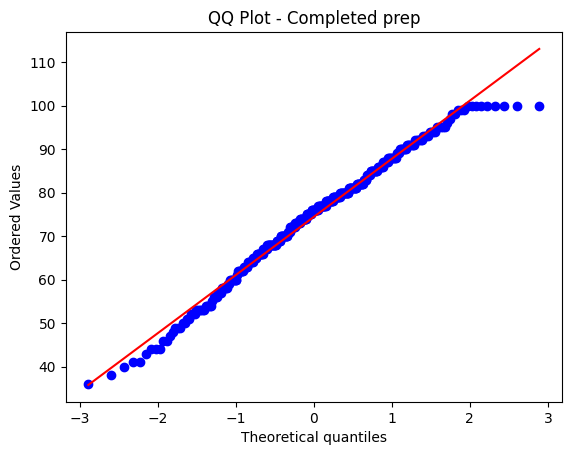

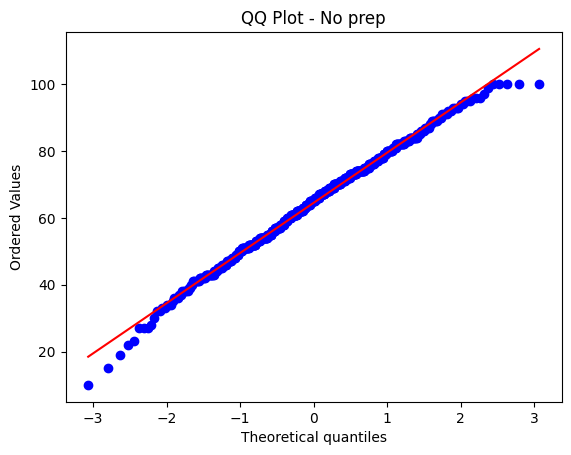

In [21]:
#QQ-plot
stats.probplot(prep, plot=plt)
plt.title("QQ Plot - Completed prep")
plt.show()

stats.probplot(no_prep, plot=plt)
plt.title("QQ Plot - No prep")
plt.show()